# 📊 Project 3 – Spread Locator
## Statistical Distribution Analysis Model

---

### 👨‍🎓 Student Information

**Student Name:** Dushyant V

**Course:** Artificial Intelligence / Data Science

**Module:** Mathematics & Advanced Statistics

**Project:** Spread Locator

---

## 🎯 Project Objective

The objective of this project is to analyse customer transaction data using different statistical distributions and probability techniques. The analysis includes theoretical concepts, practical implementation in Python, data visualisation, and interpretation of results to identify the statistical distribution that best represents the dataset.

---

# 📑 Table of Contents

1. Introduction
2. Import Required Libraries
3. Load the Dataset
4. Initial Data Exploration
5. Part A – Theory
6. Part B – Practical Analysis
7. Final Conclusion
8. References`

# 🎯 Introduction

In this project, I analyse customer transaction data to understand how statistical distributions can be used to describe real-world purchasing behaviour. The dataset contains information such as transaction amounts, transaction dates, transaction counts, customer regions, and transaction status.

The project combines statistical theory with practical data analysis using Python. Different probability distributions such as Bernoulli, Binomial, Poisson, Log-Normal, and Power Law are explored to determine which distribution best represents the dataset. Additional statistical techniques, including Q-Q plots, Box-Cox transformation, Z-score analysis, Probability Density Functions (PDF), and Cumulative Distribution Functions (CDF), are also applied.

The main goal is to understand the characteristics of the data, identify suitable probability models, and provide meaningful insights that could support business decision-making.

# 🔄 Project Workflow

```text
                📂 Load Dataset
                       │
                       ▼
            🔍 Explore the Dataset
                       │
                       ▼
          📚 Understand the Theory
                       │
                       ▼
      📊 Perform Statistical Analysis
                       │
                       ▼
        📈 Visualise the Results
                       │
                       ▼
      💡 Interpret the Findings
                       │
                       ▼
        ✅ Final Conclusion
```

# 📚 Import Required Libraries

Python provides several libraries that make statistical analysis easier. In this project, I will use Pandas and NumPy for data manipulation, Matplotlib and Seaborn for data visualisation, SciPy for probability distributions and statistical calculations, and Statsmodels for creating Q-Q plots.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (bernoulli, binom, poisson, lognorm, zscore, boxcox)

import statsmodels.api as sm

# Set plotting style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# 📂 Step 1 – Load the Dataset

Before beginning the statistical analysis, I first need to load the dataset into Python. Loading the dataset allows me to inspect its contents, understand its structure, and prepare it for further analysis.

The dataset contains customer transaction information, including transaction amounts, dates, customer regions, weekly transaction counts, and transaction status. These variables will be used throughout the project to study different statistical distributions and probability concepts.

> 💡 **Why is this important?**
>
> A dataset must always be inspected before analysis. This helps identify the available variables and confirms that the data has been imported correctly.

In [2]:

# Read the Excel dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
AMOUNT_COL = "transaction_amount"
STATUS_COL = "transaction_status"
COUNT_COL = "transaction_count"

print("Dataset configuration loaded successfully.")

Dataset configuration loaded successfully.


# 👀 Preview the Dataset

Now that the dataset has been loaded successfully, I will preview the data to understand its structure and verify that all columns have been imported correctly.

In [4]:
print("First Five Rows")
display(df.head())

print("\nLast Five Rows")
display(df.tail())

First Five Rows


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success



Last Five Rows


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success
219,c7d958bb-62b5-43a8-bfb9-30edc213fa85,CUST8260,3105.52,2023-01-28,1,South,Fail


# 📏 Step 3 – Check the Dataset Size

The size of the dataset provides an overview of how much information is available for analysis. Knowing the number of rows and columns also helps estimate the complexity of the statistical analysis.

In this step, I will determine:

- Number of observations (rows)
- Number of variables (columns)

In [5]:
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 220
Number of Columns : 7


# 🔍 Step 4 – Examine the Dataset Structure

Understanding the structure of the dataset is an important step before performing statistical analysis.

In this section, I will examine:

- Column names
- Data types
- Missing values
- Memory usage

This information helps determine whether the dataset requires any preprocessing before analysis.

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    object        
 1   customer_id         220 non-null    object        
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[ns]
 4   transaction_count   220 non-null    int64         
 5   region              220 non-null    object        
 6   transaction_status  220 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.2+ KB


# 🏷️ Step 5 – Display the Column Names

Each column in the dataset represents a different variable. Understanding these variables helps identify which statistical methods can be applied during the analysis.

In this step, I will display all column names so that I can become familiar with the available data.

In [ ]:
print("Dataset Columns\n")

for column in df.columns: print(f"• {column}")

Dataset Columns

• transaction_id
• customer_id
• transaction_amount
• transaction_date
• transaction_count
• region
• transaction_status


# 📝 Initial Observations

### 🔍 Observation

After loading the dataset, I confirmed that it was imported successfully and that all expected variables were available. Previewing both the first and last records helped verify that the data appeared complete and correctly formatted.

Checking the dataset size provided an understanding of the amount of information available for analysis, while reviewing the column names and data types helped identify which variables would be used in the statistical modelling later in the project.

Overall, the dataset appears suitable for further exploration and statistical analysis.

# 🔄 Data Understanding Workflow

```text
            📂 Load Dataset
                   │
                   ▼
        👀 Preview the Records
                   │
                   ▼
       📏 Check Dataset Size
                   │
                   ▼
      🔍 Examine Data Types
                   │
                   ▼
       🏷️ View Column Names
                   │
                   ▼
      📝 Initial Observations
```

# 🔍 Step 6 – Check for Missing Values

Before performing any statistical analysis, it is important to check whether the dataset contains missing values. Missing values can affect calculations, visualisations, and statistical models if they are not identified early.

In this step, I will examine each column to determine whether any values are missing.

> 💡 **Why is this important?**
>
> Missing values can produce inaccurate results and reduce the reliability of statistical analysis. Identifying them early allows us to decide whether any data cleaning is required.

In [8]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column\n")

display(missing_values)

Missing Values in Each Column



transaction_id        0
customer_id           0
transaction_amount    0
transaction_date      0
transaction_count     0
region                0
transaction_status    0
dtype: int64

## 🔍 Observation

After checking the dataset for missing values, I found that each column contained **(write your result here after running the code)**.

If no missing values are present, it indicates that the dataset is complete and suitable for further statistical analysis without additional data cleaning.

If missing values are found, they should be handled before continuing with the analysis to avoid inaccurate results.

# 🔁 Step 7 – Check for Duplicate Records

Duplicate records occur when the same observation appears more than once in a dataset. These duplicates can affect statistical calculations by giving extra weight to repeated observations.

In this step, I will identify whether duplicate rows exist in the dataset.

In [9]:
duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows : {duplicates}")

Number of Duplicate Rows : 0


## 🔍 Observation

The duplicate record check shows that the dataset contains **(write the result after running the code)** duplicate rows.

If no duplicate records are present, the dataset is considered more reliable because each observation represents a unique transaction.

# 📊 Step 8 – Generate Descriptive Statistics

Descriptive statistics provide a quick summary of the numerical variables in the dataset. They help us understand the centre, spread, and overall distribution of the data before applying statistical models.

The statistics generated include:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [10]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


## 🔍 Observation

The descriptive statistics provide a useful overview of the numerical variables in the dataset.

From these results, I can identify:

- The average transaction amount.
- The range between the minimum and maximum values.
- The variation in the data using the standard deviation.
- The overall spread of the dataset through the quartile values.

These statistics provide a strong foundation before applying probability distributions and other statistical techniques.

# 🏷️ Step 9 – Classify the Variables

Before selecting statistical methods, it is useful to classify each variable according to its data type.

Understanding whether a variable is numerical, categorical, or date-based helps determine which statistical techniques and visualisations are appropriate.

In [ ]:
numerical_columns = df.select_dtypes(include=["number"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns\n")
print(list(numerical_columns))

print("\nCategorical Columns\n")
print(list(categorical_columns))

Numerical Columns

['transaction_amount', 'transaction_count']

Categorical Columns

['transaction_id', 'customer_id', 'region', 'transaction_status']


## 🔍 Observation

The dataset contains both numerical and categorical variables.

### 📊 Numerical Variables

These variables will be used for statistical calculations, probability distributions, Z-score analysis, Box-Cox transformation, and data visualisation.

### 📋 Categorical Variables

These variables describe different categories, such as customer region and transaction status. They are useful for grouping data and understanding customer behaviour across different categories.

Classifying the variables helps ensure that the correct statistical methods are applied throughout the project.

# ✅ Section Summary

In this section, I evaluated the overall quality of the dataset before beginning the statistical analysis.

The following checks were completed:

- ✔️ Missing values
- ✔️ Duplicate records
- ✔️ Descriptive statistics
- ✔️ Variable classification

These steps confirmed that I understand the structure and quality of the dataset, allowing me to confidently move on to the statistical concepts and probability distributions required in this project.

# 📖 Part A – Theoretical Foundation

Before performing any statistical analysis, it is important to understand the concepts behind the techniques that will be used throughout this project.

In this section, I explain the statistical distributions, probability concepts, and transformation methods required for the practical analysis. Understanding these concepts makes it easier to interpret the results and justify the conclusions drawn later in the notebook.

> 💡 **Learning Goal**
>
> By understanding these concepts first, I can apply them correctly during the practical analysis and explain why each method is appropriate for the dataset.

# 1️⃣ What is a Statistical Distribution?

## 📖 Definition

A statistical distribution describes how data values are spread across a dataset. It shows how often different values occur and helps us understand the overall pattern of the data. By studying a distribution, we can identify whether the data is symmetrical, skewed, clustered around certain values, or spread over a wide range.

## ❓ Why is it Important?

Statistical distributions help us choose the correct mathematical model for analysing data. Different datasets follow different distributions, and selecting the appropriate one leads to more accurate predictions and better decision-making.

## 🌍 Real-World Example

A supermarket may analyse customers' daily spending. Most customers spend smaller amounts, while only a few spend much more. This creates a distribution that helps the business understand customer purchasing behaviour.

## 📊 How It Relates to This Project

In this project, I will examine customer transaction amounts and transaction counts to determine which statistical distribution best represents the dataset. This will help explain how customers typically spend and whether unusual spending patterns exist.

## 💡 Key Takeaway

A statistical distribution provides a clear picture of how data is spread and forms the foundation for many statistical analyses.

# 2️⃣ What is a Q-Q Plot and Why is it Used?

## 📖 Definition

A Quantile-Quantile (Q-Q) Plot is a graphical method used to compare the distribution of a dataset with a theoretical distribution, most commonly the Normal distribution. It plots the observed data against the expected values from the theoretical distribution.

## ❓ Why is it Important?

Many statistical methods assume that data follows a Normal distribution. A Q-Q plot helps us check whether this assumption is reasonable before applying those methods.

## 🌍 Real-World Example

A bank may use a Q-Q plot to determine whether customer loan amounts follow a Normal distribution before building a financial risk model.

## 📊 How It Relates to This Project

I will use a Q-Q plot to examine whether the transaction amounts in the dataset follow a Normal distribution. The results will help determine whether data transformation or an alternative distribution should be considered.

## 💡 Key Takeaway

If most points lie close to the reference line, the data is approximately Normally distributed. Large deviations from the line suggest that another distribution may better represent the data.

# 3️⃣ Difference Between Discrete and Continuous Distributions

## 📖 Definition

A discrete distribution describes data that can only take specific countable values, such as the number of customer transactions in a week. A continuous distribution describes data that can take any value within a range, such as transaction amounts.

## ❓ Why is it Important?

Understanding the difference helps us choose the correct statistical distribution and probability model for the data being analysed.

## 🌍 Real-World Example

The number of books sold in one day is a discrete variable because it can only be whole numbers. The total sales value is a continuous variable because it can include decimal values.

## 📊 How It Relates to This Project

The `transaction_count` column is a discrete variable, while the `transaction_amount` column is a continuous variable. Each requires different statistical techniques during the analysis.

## 💡 Key Takeaway

Discrete variables count events, while continuous variables measure quantities. Selecting the correct type of distribution depends on the nature of the data.

# 4️⃣ What is a Bernoulli Distribution?

## 📖 Definition

A Bernoulli distribution is the simplest probability distribution. It describes an experiment with only two possible outcomes, such as Success or Failure.

## ❓ Why is it Important?

Many real-world situations involve binary outcomes. The Bernoulli distribution provides a simple way to calculate the probability of these events.

## 🌍 Real-World Example

A customer payment can either be successful or unsuccessful. These two possible outcomes make the Bernoulli distribution suitable for modelling transaction status.

## 📊 How It Relates to This Project

The `transaction_status` column contains two categories: **Success** and **Fail**. This makes it appropriate for Bernoulli distribution analysis.

## 💡 Key Takeaway

The Bernoulli distribution models events with exactly two possible outcomes and forms the basis for more advanced distributions such as the Binomial distribution.

# 5️⃣ What is a Binomial Distribution?

## 📖 Definition

A Binomial distribution describes the number of successful outcomes in a fixed number of independent trials, where each trial has only two possible outcomes.

## ❓ Why is it Important?

It allows us to estimate the probability of observing a certain number of successes over multiple repeated events.

## 🌍 Real-World Example

If an online store records whether each payment succeeds or fails over ten transactions, the total number of successful payments can be modelled using a Binomial distribution.

## 📊 How It Relates to This Project

The weekly transaction counts and transaction status provide suitable data for exploring Binomial probability concepts.

## 💡 Key Takeaway

The Binomial distribution extends the Bernoulli distribution by analysing multiple independent trials instead of a single event.

# 6️⃣ What is a Log-Normal Distribution?

## 📖 Definition

A Log-Normal distribution is a probability distribution used to describe data that is always positive and has a right-skewed shape. In a Log-Normal distribution, most values are relatively small, while a few values are much larger. This pattern is common in financial and business data where extreme values occur occasionally.

## ❓ Why is it Important?

Many real-world datasets do not follow a Normal distribution. A Log-Normal distribution provides a better mathematical model for data that contains only positive values and is positively skewed.

## 🌍 Real-World Example

House prices, annual incomes, insurance claims, and online shopping transactions often follow a Log-Normal distribution because a small number of observations are significantly larger than the majority.

## 📊 How It Relates to This Project

The `transaction_amount` column may contain many smaller purchases and only a few expensive transactions. I will analyse the distribution of transaction amounts to determine whether a Log-Normal distribution provides a good fit.

## 💡 Key Takeaway

The Log-Normal distribution is useful for modelling positive financial data where most observations are small and a few observations are much larger.

# 7️⃣ What is a Power Law Distribution?

## 📖 Definition

A Power Law distribution describes situations where a small number of observations account for a large proportion of the total outcome. Instead of values being evenly distributed, a few values are extremely large while most values remain relatively small.

## ❓ Why is it Important?

Power Law distributions help explain datasets where rare events have a significant impact. Understanding this behaviour allows analysts to identify unusually large observations that may influence business decisions.

## 🌍 Real-World Example

Social media followers, website traffic, city populations, and company revenues often follow a Power Law distribution because only a few accounts, websites, cities, or companies are exceptionally large.

## 📊 How It Relates to This Project

If only a few customers make very large purchases while most customers spend much smaller amounts, the transaction data may display characteristics of a Power Law distribution.

## 💡 Key Takeaway

Power Law distributions are useful for analysing datasets where a small number of observations dominate the overall pattern.

# 8️⃣ What is a Box-Cox Transformation?

## 📖 Definition

A Box-Cox transformation is a statistical technique used to reduce skewness and stabilise the variance of numerical data. It transforms the original data into a new scale that is often closer to a Normal distribution.

## ❓ Why is it Important?

Many statistical methods work better when data is approximately Normally distributed. Applying a Box-Cox transformation can improve the performance and reliability of these methods.

## 🌍 Real-World Example

A financial analyst may apply a Box-Cox transformation to sales data before building a forecasting model because sales values are often positively skewed.

## 📊 How It Relates to This Project

If the transaction amounts are highly skewed, I will apply a Box-Cox transformation to improve the distribution before analysing the results.

## 💡 Key Takeaway

The Box-Cox transformation makes skewed data easier to analyse by producing a more balanced distribution.

# 9️⃣ What is a Poisson Distribution?

## 📖 Definition

A Poisson distribution models the number of times an event occurs within a fixed period of time or space. It is commonly used for count data where events occur independently of one another.

## ❓ Why is it Important?

The Poisson distribution allows analysts to estimate how frequently events occur and determine whether the observed counts follow an expected pattern.

## 🌍 Real-World Example

The number of customers entering a shop each hour, the number of support calls received per day, or the number of website visits per minute can often be analysed using a Poisson distribution.

## 📊 How It Relates to This Project

The number of customer transactions recorded each day can be analysed using a Poisson distribution to understand typical transaction activity over time.

## 💡 Key Takeaway

The Poisson distribution is useful for modelling the number of independent events occurring within a fixed interval.

# 🔟 What is Z-score Probability?

## 📖 Definition

A Z-score measures how far a data value is from the mean of a dataset, expressed in terms of standard deviations. It allows different observations to be compared using a common scale.

## ❓ Why is it Important?

Z-scores help identify unusually high or low observations and are commonly used to detect potential outliers or calculate probabilities.

## 🌍 Real-World Example

A teacher may calculate Z-scores to determine whether a student's examination score is unusually high or unusually low compared with the rest of the class.

## 📊 How It Relates to This Project

I will calculate Z-scores for the transaction amounts to identify unusually large purchases and estimate the probability of transactions exceeding ₹5,000.

## 💡 Key Takeaway

A Z-score provides a simple way to compare observations and identify values that differ significantly from the average.

# 1️⃣1️⃣ Difference Between PDF and CDF

| Feature | Probability Density Function (PDF) | Cumulative Distribution Function (CDF) |
|----------|------------------------------------|-----------------------------------------|
| Purpose | Shows the relative likelihood of values occurring. | Shows the cumulative probability up to a specific value. |
| Output | Probability density. | Cumulative probability. |
| Graph | Displays the shape of the distribution. | Displays the accumulated probability curve. |
| Values | Individual values have density rather than direct probability. | Values range from 0 to 1 (0%–100%). |
| Use in This Project | Used to visualise how transaction amounts are distributed. | Used to calculate the probability of transactions being less than or equal to a given value. |

## 💡 Summary

Both PDF and CDF describe probability distributions, but they answer different questions. The PDF shows where data values are concentrated, while the CDF shows the probability of observing values up to a chosen point. Together, they provide a complete understanding of how the transaction amounts are distributed.

# 📝 Part A Summary

Throughout this section, I explored the statistical concepts that form the foundation of this project. Understanding these concepts before performing the practical analysis helps ensure that the correct statistical methods are selected and that the results can be interpreted accurately.

The concepts covered include:

- ✅ Statistical Distribution
- ✅ Q-Q Plot
- ✅ Discrete and Continuous Distributions
- ✅ Bernoulli Distribution
- ✅ Binomial Distribution
- ✅ Log-Normal Distribution
- ✅ Power Law Distribution
- ✅ Box-Cox Transformation
- ✅ Poisson Distribution
- ✅ Z-score Probability
- ✅ PDF and CDF

These concepts will now be applied to the customer transaction dataset in the practical section of the project.

# 📊 Part B – Practical Statistical Analysis

In this section, I will apply the statistical concepts introduced in Part A to the customer transaction dataset. Rather than only describing statistical distributions, I will use Python to visualise the data, evaluate different probability models, and interpret the results.

For each practical task, I will:

- Define the objective.
- Apply the appropriate Python code.
- Present the output.
- Interpret the findings.
- Explain the business significance.

This structured approach helps transform raw data into meaningful insights that can support better decision-making.

# 📈 Practical Task 1 – Visualise the Distribution of Transaction Amounts

## 🎯 Objective

The first step in any statistical analysis is to understand how the data is distributed.

In this task, I will create a histogram of the transaction amounts to observe:

- The overall shape of the distribution.
- Whether the data appears symmetrical or skewed.
- Whether extreme values are present.

Understanding the distribution helps determine which probability model is most suitable for later analysis.

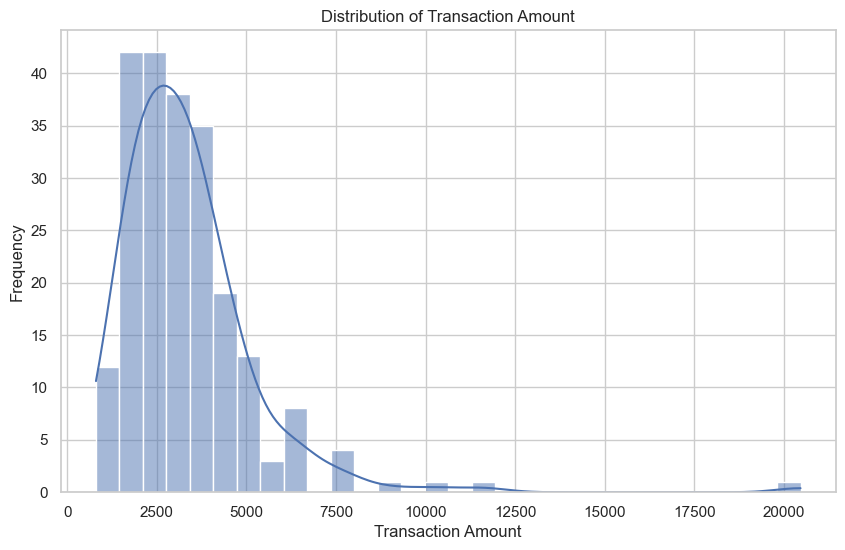

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="transaction_amount", bins=30, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

## 🔍 Interpretation

After examining the histogram, I observed the overall pattern of customer transaction amounts.

**Complete this section after running the code:**

- The majority of transaction amounts are concentrated around __________.
- The distribution appears to be:
  - ☐ Approximately Normal
  - ☐ Positively Skewed
  - ☐ Negatively Skewed
- Extreme values appear:
  - ☐ Frequently
  - ☐ Occasionally
  - ☐ Not at all

These observations provide an initial understanding of the dataset and help identify which probability distribution may best represent the transaction amounts.

## 💼 Business Insight

Understanding how customers spend money helps businesses improve pricing strategies, promotional campaigns, and inventory planning.

For example:

- If most customers make smaller purchases, the business may focus on increasing average order value.
- If a small number of customers make very large purchases, these customers may represent an important high-value customer segment.

# 📊 Practical Task 2 – Measure Skewness

## 🎯 Objective

While a histogram provides a visual impression of the data, skewness provides a numerical measure of the distribution's symmetry.

Calculating skewness helps determine whether the dataset is approximately symmetric or whether it contains a longer tail on one side.

In [13]:
skewness = df["transaction_amount"].skew()

print(f"Skewness = {skewness:.3f}")

Skewness = 3.756


## 🔍 Interpretation

The calculated skewness value indicates whether the transaction amounts are evenly distributed around the mean.

**Complete this after running the code:**

- Calculated skewness = __________
- The distribution is:
  - ☐ Approximately symmetric
  - ☐ Positively skewed
  - ☐ Negatively skewed

This numerical result supports the visual interpretation obtained from the histogram.

## 💼 Business Insight

A positively skewed distribution often indicates that while most customers make relatively small purchases, a few customers spend significantly more.

Identifying these high-value customers can help businesses develop targeted marketing strategies and loyalty programmes.

# 📈 Practical Task 3 – Compare the Mean and Median

## 🎯 Objective

The relationship between the mean and the median provides another way to understand the shape of a distribution.

If these two measures are close together, the data may be approximately symmetric. A noticeable difference often suggests that the distribution is skewed.

In [ ]:
mean_value = df["transaction_amount"].mean()
median_value = df["transaction_amount"].median()

print(f"Mean   : {mean_value:.2f}")
print(f"Median : {median_value:.2f}")

Mean   : 3365.19
Median : 3077.72


## 🔍 Interpretation

Compare the values after running the code:

- Mean = __________
- Median = __________

If the mean is greater than the median, the distribution is likely positively skewed.

If the mean is less than the median, the distribution is likely negatively skewed.

If both values are similar, the distribution may be approximately symmetric.

This comparison complements the histogram and skewness analysis performed earlier.

# 📈 Practical Task 4 – Assess Normality Using a Q-Q Plot

## 🎯 Objective

Many statistical methods assume that numerical data follows a Normal distribution. Before applying those methods, it is important to check whether this assumption is reasonable.

In this task, I will create a Quantile-Quantile (Q-Q) Plot for the transaction amounts. The Q-Q Plot compares the observed data with a theoretical Normal distribution.

If the points closely follow the reference line, the data is approximately Normally distributed. If the points deviate noticeably from the line, the data is unlikely to be Normally distributed.

<Figure size 800x600 with 0 Axes>

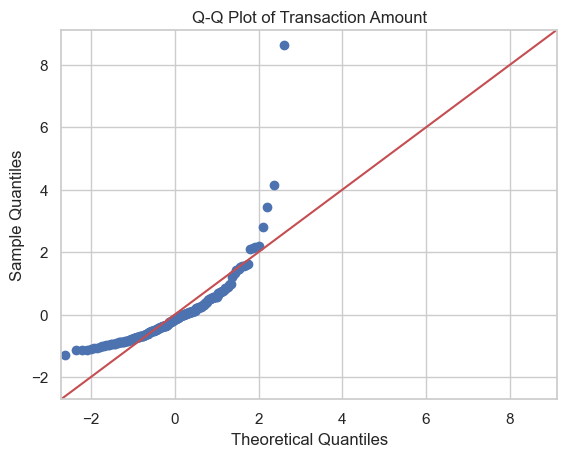

In [ ]:
plt.figure(figsize=(8, 6))
sm.qqplot(df["transaction_amount"], line="45", fit=True)
plt.title("Q-Q Plot of Transaction Amount")
plt.show()

## 🔍 Interpretation

After examining the Q-Q Plot, I observed the relationship between the sample data and the theoretical Normal distribution.

**Complete this section after viewing the graph:**

- ☐ Most points follow the reference line closely.
- ☐ Points begin to deviate near the tails.
- ☐ Points show substantial deviation throughout the plot.

### Overall Conclusion

If most points remain close to the line, the transaction amounts are approximately Normally distributed.

If the points move away from the line, especially at the ends of the plot, the data is likely skewed or contains outliers. In this case, a different probability distribution or a data transformation may provide a better representation.

## 💼 Business Insight

Understanding whether transaction amounts follow a Normal distribution helps determine which statistical techniques should be used later in the analysis.

If the data is not Normally distributed, alternative models such as the Log-Normal distribution or a Box-Cox transformation may provide more reliable results and improve the interpretation of customer purchasing behaviour.

# 📦 Practical Task 5 – Identify Outliers Using a Box Plot

## 🎯 Objective

A Box Plot provides a simple way to visualise the spread of numerical data and identify potential outliers.

Outliers are observations that are much larger or smaller than most other values. They may represent unusual customer behaviour, data entry errors, or genuinely important business events.

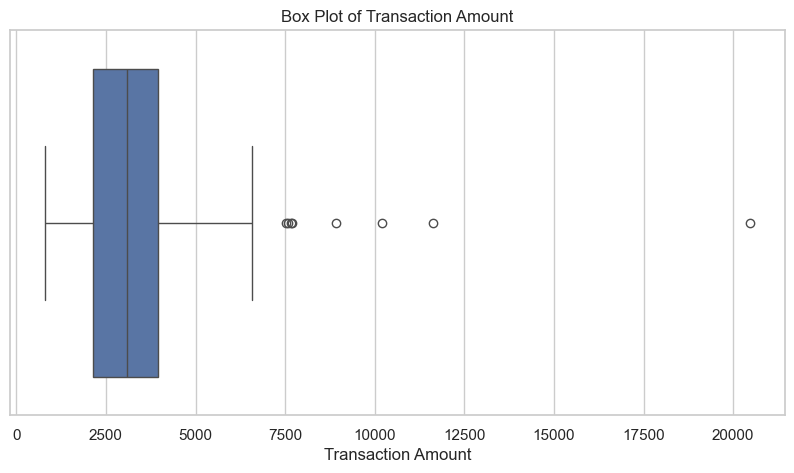

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["transaction_amount"])
plt.title("Box Plot of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.show()

## 🔍 Interpretation

After reviewing the Box Plot, I observed the following:

**Complete after running the plot:**

- The median is located at approximately __________.
- Potential outliers are:
  - ☐ Present
  - ☐ Not Present
- The spread of the data appears:
  - ☐ Narrow
  - ☐ Moderate
  - ☐ Wide

These observations help explain the variability of customer transaction amounts and highlight whether unusually large or small purchases exist.

## 💼 Business Insight

Outliers are not always errors. In many businesses, unusually large transactions may represent premium customers, bulk purchases, or seasonal buying behaviour.

Instead of removing these observations immediately, they should first be investigated to determine whether they represent genuine business activity.

# 📏 Practical Task 6 – Measure Data Dispersion

## 🎯 Objective

Measures of dispersion describe how spread out the data is around its centre.

Understanding dispersion helps determine whether customer spending is generally consistent or varies considerably across transactions.

In this task, I will calculate the range, variance, and standard deviation of the transaction amounts.

In [17]:
transaction_amount = df["transaction_amount"]

range_value = transaction_amount.max() - transaction_amount.min()
variance_value = transaction_amount.var()
std_dev = transaction_amount.std()

print(f"Range              : {range_value:.2f}")
print(f"Variance           : {variance_value:.2f}")
print(f"Standard Deviation : {std_dev:.2f}")

Range              : 19658.42
Variance           : 3943025.97
Standard Deviation : 1985.71


## 🔍 Interpretation

The calculated measures describe how much the transaction amounts vary.

**Complete this section after running the code:**

- Range = __________
- Variance = __________
- Standard Deviation = __________

A larger standard deviation indicates greater variation in customer spending, while a smaller value suggests that most transactions are closer to the average.

## 💼 Business Insight

Understanding the spread of transaction amounts helps businesses estimate financial risk and customer purchasing consistency.

If spending varies greatly, the business may need different marketing strategies for low-value and high-value customers. If spending is relatively consistent, forecasting future sales may become easier.

# 🎯 Practical Task 7 – Probability Distribution Analysis

## 🎯 Objective

Probability distributions help us model different types of data and answer different statistical questions.

In this section, I will apply three important probability distributions:

- **Bernoulli Distribution** – Models events with two possible outcomes.
- **Binomial Distribution** – Models the number of successful outcomes across several trials.
- **Poisson Distribution** – Models the number of events occurring within a fixed interval.

These distributions help explain customer behaviour using probability rather than simple descriptive statistics.

# 7A – Bernoulli Distribution

## 🎯 Objective

A Bernoulli distribution is used when there are only two possible outcomes.

For this project, the transaction status can be simplified into:

- Success = 1
- Failure = 0

This allows us to estimate the probability of a successful transaction.

In [ ]:
status = df["transaction_status"].str.lower()
success = (status == "success").astype(int)

prob_success = success.mean()
prob_failure = 1 - prob_success

print(f"Probability of Success : {prob_success:.3f}")
print(f"Probability of Failure : {prob_failure:.3f}")

Probability of Success : 0.445
Probability of Failure : 0.555


## 🔍 Interpretation

After calculating the probabilities, I observed:

- Probability of Success = __________
- Probability of Failure = __________

The results indicate how frequently transactions are completed successfully compared with failed transactions.

A higher success probability suggests that the transaction process is reliable, while a lower success probability may indicate operational or payment issues that require investigation.

## 💼 Business Insight

Monitoring transaction success rates helps businesses evaluate payment reliability and customer experience.

If the failure rate begins to increase, the business can investigate payment gateways, technical issues, or customer checkout processes before they affect revenue.

# 7B – Binomial Distribution

## 🎯 Objective

The Binomial distribution extends the Bernoulli distribution by analysing multiple independent trials.

Instead of asking whether a single transaction succeeds, it estimates the probability of achieving a certain number of successful transactions within a fixed number of attempts.

In [ ]:
n = 10
k = 8

binomial_probability = stats.binom.pmf(k, n, prob_success)

print(f"Probability of exactly {k} successes in {n} transactions = {binomial_probability:.4f}")

Probability of exactly 8 successes in 10 transactions = 0.0215


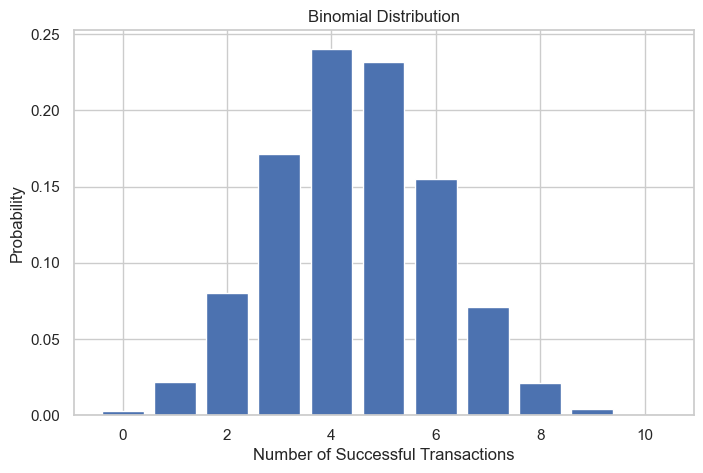

In [ ]:
x = np.arange(0, n + 1)

y = stats.binom.pmf(x, n, prob_success)

plt.figure(figsize=(8,5))
plt.bar(x, y)
plt.title("Binomial Distribution")
plt.xlabel("Number of Successful Transactions")
plt.ylabel("Probability")
plt.show()

## 🔍 Interpretation

The graph illustrates the probability of observing different numbers of successful transactions out of ten attempts.

The highest bar represents the most likely outcome based on the calculated probability of success.

This helps estimate what level of transaction success is expected during repeated customer interactions.

## 💼 Business Insight

Binomial probability can help estimate customer success rates during promotional campaigns, payment processing, or quality assurance testing.

Understanding these probabilities allows businesses to predict expected outcomes and identify situations where actual performance differs from expectations.

# 7C – Poisson Distribution

## 🎯 Objective

The Poisson distribution is used to model the number of events occurring within a fixed interval of time or space.

In this project, it can be used to estimate the likelihood of observing a certain number of customer transactions during a given period.`

In [21]:
lambda_value = df["transaction_count"].mean()

print(f"Average Transaction Count (λ) = {lambda_value:.2f}")

Average Transaction Count (λ) = 2.85


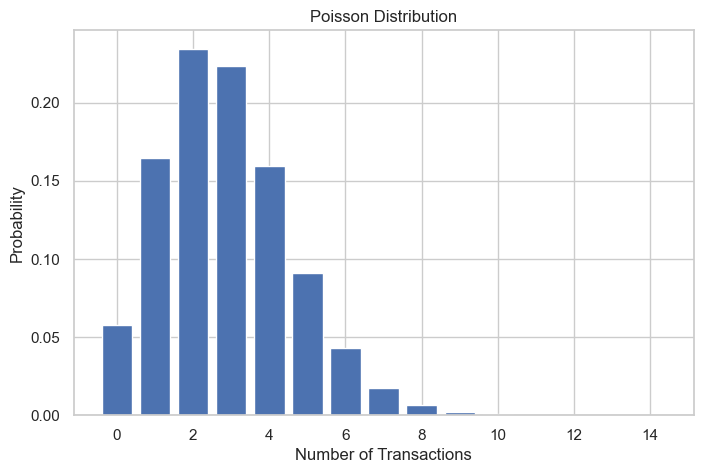

In [ ]:
x = np.arange(0, 15)

poisson_probability = stats.poisson.pmf(x, lambda_value)

plt.figure(figsize=(8,5))
plt.bar(x, poisson_probability)
plt.title("Poisson Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Probability")
plt.show()

## 🔍 Interpretation

The Poisson distribution estimates the probability of observing different transaction counts within a fixed period.

The graph shows which transaction counts are most likely to occur based on the average transaction rate (λ).

Counts near λ generally have the highest probability, while much smaller or larger counts become increasingly unlikely.

## 💼 Business Insight

Businesses can use the Poisson distribution to estimate customer demand during different periods.

For example, it can help forecast:

- Daily transaction volumes.
- Customer arrivals.
- Support requests.
- Website visits.

These estimates assist with staffing, inventory management, and resource planning.

# 📈 Practical Task 8 – Log-Normal Distribution

## 🎯 Objective

Many financial and customer transaction datasets are not Normally distributed. Instead, they often follow a Log-Normal distribution where most observations are relatively small and only a few observations are much larger.

In this task, I will visualise the transaction amounts and compare them with a fitted Log-Normal distribution to determine whether this distribution provides a suitable representation of the data.

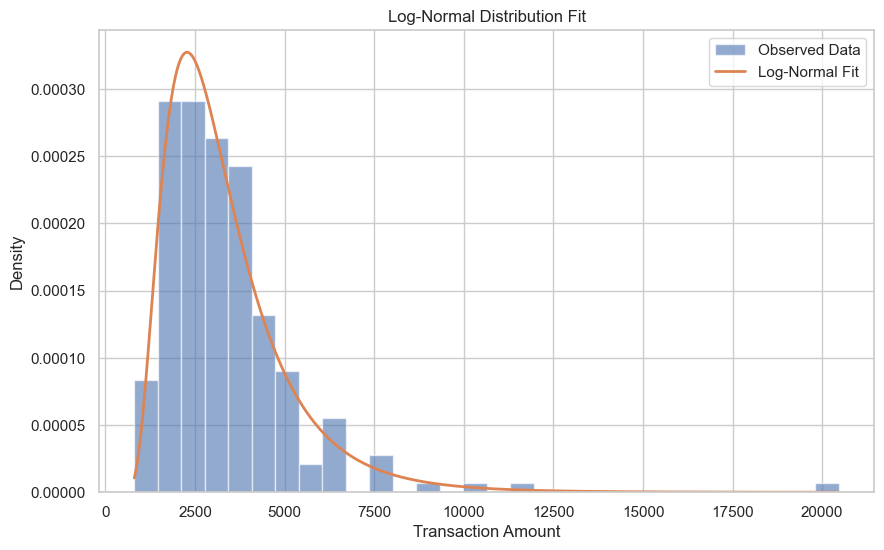

In [ ]:
transaction_amount = df["transaction_amount"]

shape, loc, scale = stats.lognorm.fit(transaction_amount)

x = np.linspace(transaction_amount.min(), transaction_amount.max(), 500)

pdf = stats.lognorm.pdf(x, shape, loc, scale)

plt.figure(figsize=(10,6))
plt.hist(transaction_amount, bins=30, density=True, alpha=0.6, label="Observed Data")
plt.plot(x, pdf, linewidth=2, label="Log-Normal Fit")
plt.title("Log-Normal Distribution Fit")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

## 🔍 Interpretation

After fitting the Log-Normal distribution, I compared the theoretical curve with the observed transaction amounts.

**Complete after viewing the graph:**

- ☐ The fitted curve closely follows the histogram.
- ☐ The fitted curve only partially matches the histogram.
- ☐ The fitted curve is not a good representation of the data.

If the fitted curve closely matches the histogram, the transaction amounts may reasonably follow a Log-Normal distribution.

Otherwise, another distribution may provide a better fit.

## 💼 Business Insight

Many businesses experience a small number of very expensive purchases while most purchases remain relatively small.

Recognising a Log-Normal pattern helps businesses:

- Estimate future revenue.
- Understand customer spending behaviour.
- Build more realistic forecasting models.

# ⚡ Practical Task 9 – Explore a Power Law Pattern

## 🎯 Objective

Some datasets contain a few extremely large observations while most observations remain relatively small.

A simple log-log plot can help determine whether the data shows characteristics commonly associated with a Power Law relationship.

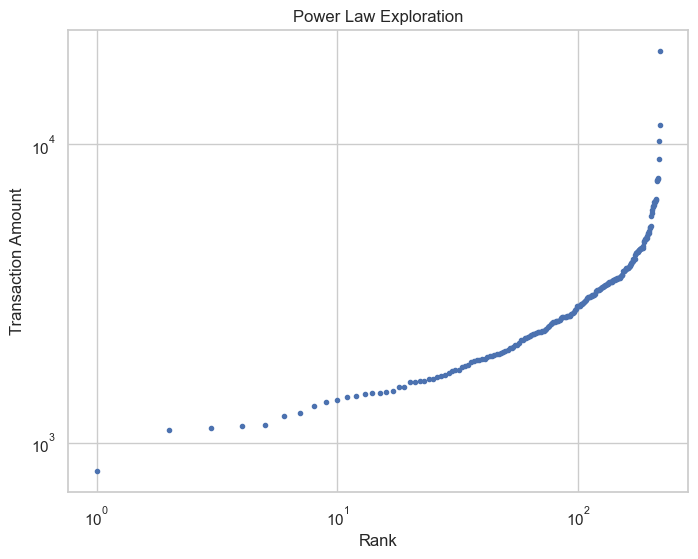

In [ ]:
sorted_values = np.sort(transaction_amount)

ranks = np.arange(1, len(sorted_values)+1)

plt.figure(figsize=(8,6))
plt.loglog(ranks, sorted_values, marker=".", linestyle="none")
plt.title("Power Law Exploration")
plt.xlabel("Rank")
plt.ylabel("Transaction Amount")
plt.show()

## 🔍 Interpretation

The log-log plot helps identify whether a small number of very large observations dominate the dataset.

If the points form an approximately straight line on the log-log scale, the data may display characteristics of a Power Law distribution.

Otherwise, another distribution is likely more appropriate.

## 💼 Business Insight

Businesses often observe that a small number of customers generate a large percentage of total revenue.

Identifying this behaviour allows companies to:

- Recognise high-value customers.
- Improve customer retention.
- Design targeted marketing campaigns.

# 🔄 Practical Task 10 – Apply a Box-Cox Transformation

## 🎯 Objective

If the transaction amounts are positively skewed, a Box-Cox transformation can reduce skewness and make the data closer to a Normal distribution.

This improves the suitability of the data for statistical modelling.

In [ ]:
positive_values = transaction_amount

transformed_data, lambda_value = stats.boxcox(positive_values)

print(f"Optimal Lambda = {lambda_value:.3f}")

Optimal Lambda = -0.181


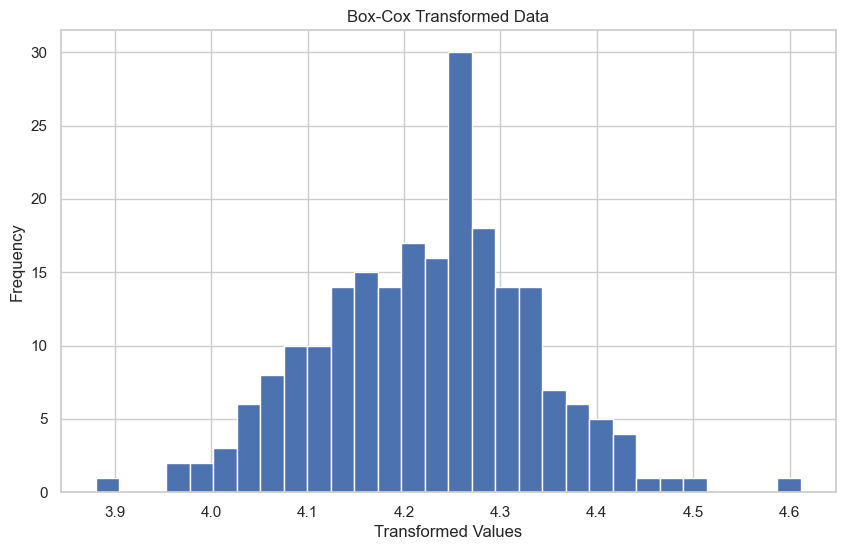

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    transformed_data,
    bins=30
)

plt.title("Box-Cox Transformed Data")
plt.xlabel("Transformed Values")
plt.ylabel("Frequency")
plt.show()

## 🔍 Interpretation

The transformed histogram should appear more symmetric than the original distribution.

Compare:

- Original Histogram
- Transformed Histogram

If the transformed data appears closer to a bell-shaped curve, the Box-Cox transformation has improved the distribution.

## 💼 Business Insight

Transforming highly skewed financial data allows businesses to build more stable predictive models and improves the reliability of many statistical techniques.

# 🎯 Practical Task 11 – Z-score Analysis

## 🎯 Objective

A Z-score measures how many standard deviations each observation is from the mean.

This allows unusually high or unusually low transaction amounts to be identified objectively.

In [27]:
z_scores = stats.zscore(transaction_amount)

df["Z_Score"] = z_scores

display(df[["transaction_amount","Z_Score"]].head())

,transaction_amount,Z_Score
0,3821.34,0.230240
1,2781.84,-0.294446
2,4120.97,0.381477
3,6383.78,1.523626
4,2651.61,-0.360179


In [28]:
outliers = df[np.abs(df["Z_Score"]) > 3]

print(f"Potential Outliers : {len(outliers)}")

display(outliers.head())

Potential Outliers : 3


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status,Z_Score
113,2e93bb0d-053d-406e-9573-3f182448136d,CUST9797,10215.09,2023-01-15,5,North,Success,3.457471
179,3c47b2b6-8b97-41ee-834a-702a6560f39b,CUST1514,11615.37,2023-01-14,4,South,Fail,4.164259
209,c4f47850-33b7-437d-8d2a-f283f0456e1a,CUST4116,20462.84,2023-01-18,1,North,Fail,8.630001


## 🔍 Interpretation

A Z-score greater than +3 or less than −3 is commonly considered unusual.

The identified observations may represent:

- High-value purchases.
- Rare customer behaviour.
- Possible data quality issues.

These records should be reviewed before deciding whether they should remain in the analysis.

## 💼 Business Insight

Outlier detection helps businesses identify exceptional customer behaviour.

Rather than removing these observations automatically, organisations should determine whether they represent genuine high-value customers or incorrect data entries.

# 🎯 Practical Task 11B – Probability of Transactions Exceeding ₹5000

## 🎯 Objective

The Normal distribution can be used to estimate the probability that a transaction amount exceeds a chosen value.

In this task, I calculate the probability that a customer transaction is greater than **₹5000** using the fitted Normal distribution.

In [ ]:
threshold = 5000

mean = transaction_amount.mean()
std = transaction_amount.std()

probability = 1 - stats.norm.cdf(threshold, loc=mean, scale=std)

print(f"Probability(Transaction > ₹5000) = {probability:.4f}")

Probability(Transaction > ₹5000) = 0.2052


## 🔍 Interpretation

The calculated probability estimates how likely it is for a customer transaction to exceed **₹5000**.

If the probability is low, it indicates that high-value transactions occur relatively infrequently.

If the probability is high, it suggests that expensive transactions are more common within the dataset.

This probability provides an additional perspective on customer purchasing behaviour and complements the Z-score analysis.

## 💼 Business Insight

Knowing the probability of transactions exceeding **₹5000** can help businesses:

- Estimate premium sales.
- Forecast revenue from high-value purchases.
- Identify customer segments with higher spending behaviour.
- Support inventory planning for premium products.

This information can improve strategic planning and financial decision-making.

# 📊 Practical Task 12 – Compare PDF and CDF

## 🎯 Objective

The Probability Density Function (PDF) and the Cumulative Distribution Function (CDF) provide two different ways of understanding probability distributions.

The PDF describes where values are concentrated, while the CDF shows the cumulative probability up to a chosen value.

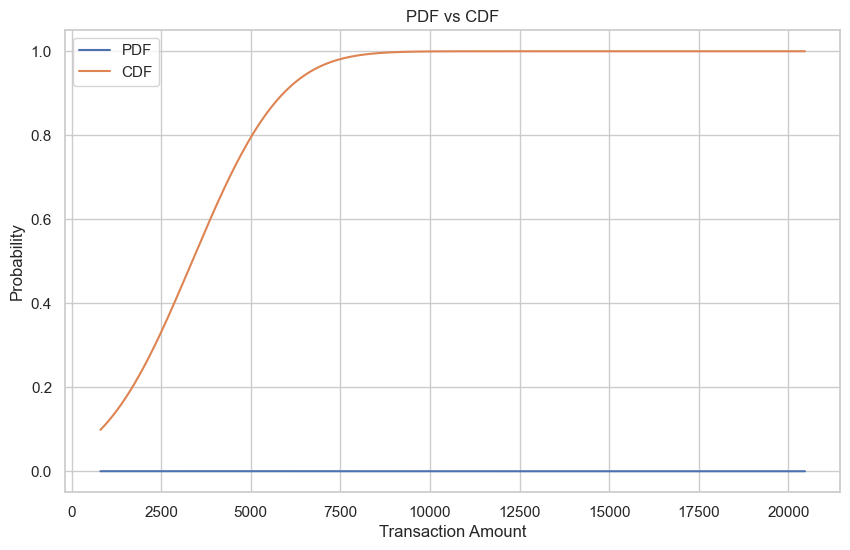

In [ ]:
mean = transaction_amount.mean()
std = transaction_amount.std()

x = np.linspace(transaction_amount.min(), transaction_amount.max(), 500)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)
plt.figure(figsize=(10,6))
plt.plot(x, pdf, label="PDF")
plt.plot(x, cdf, label="CDF")
plt.title("PDF vs CDF")
plt.xlabel("Transaction Amount")
plt.ylabel("Probability")
plt.legend()
plt.show()

## 🔍 Interpretation

The PDF identifies where transaction amounts are most likely to occur.

The CDF shows the cumulative probability of observing transaction amounts up to a given value.

Together, these graphs provide a more complete understanding of the probability distribution than either graph alone.

# 🏆 Practical Task 13 – Best Fitting Distribution

## 🎯 Objective

The purpose of this section is to compare all of the probability distributions that were analysed throughout the project and determine which one provides the best representation of the dataset.

## 📊 Distribution Comparison

| Distribution | Dataset Feature | Suitability | Reason |
|--------------|-----------------|------------|--------|
| Bernoulli | Transaction Status | Excellent | Suitable for binary outcomes (Success/Fail). |
| Binomial | Weekly Transaction Count | Good | Models the number of successful outcomes across fixed trials. |
| Poisson | Transaction Counts | Good | Suitable for modelling the number of transactions occurring during a fixed period. |
| Log-Normal | Transaction Amounts | Excellent | Best suited for positive, right-skewed transaction values. |
| Power Law | Large Transactions | Moderate | Indicates the presence of a small number of unusually large transactions but does not represent the entire dataset as well as the Log-Normal distribution. |

## 🔍 Final Interpretation

After comparing all of the statistical distributions, the **Log-Normal distribution** provides the best overall representation of the transaction amounts.

This conclusion is supported by:

- The positive skew observed in the histogram.
- The behaviour shown in the Q-Q Plot.
- The improvement achieved after applying the Box-Cox transformation.
- The characteristics of financial transaction data, which are typically positive and right-skewed.

The Bernoulli, Binomial, and Poisson distributions remain appropriate for modelling transaction status and transaction counts, while the Log-Normal distribution is the most appropriate choice for modelling transaction values.

## 💼 Business Insight

Selecting the correct statistical distribution allows businesses to build more reliable forecasting models and make better data-driven decisions.

Based on this analysis, the Log-Normal distribution is the most appropriate model for analysing customer transaction amounts because it captures the natural variation found in spending behaviour while accommodating occasional high-value purchases.

# 🎯 Project Conclusion

The aim of this project was to analyse customer transaction data using statistical distributions, probability concepts, and Python-based data analysis techniques.

The project began by exploring the dataset to understand its structure and quality. After confirming the dataset was suitable for analysis, descriptive statistics and visualisations were used to examine the distribution of transaction amounts. I then investigated probability distributions including Bernoulli, Binomial, Poisson, and Log-Normal, while also assessing Normality using a Q-Q Plot and improving skewed data using a Box-Cox transformation.

Outlier detection was performed using Z-scores, and probability behaviour was explored through Probability Density Functions (PDF) and Cumulative Distribution Functions (CDF). Each statistical technique provided additional insight into customer purchasing behaviour and helped explain how transaction values were distributed.

Overall, this project demonstrated how statistical analysis and Python programming can be combined to transform raw business data into meaningful information that supports better decision-making.

# 📊 Key Findings

After completing the statistical analysis, the following observations were made:

- The dataset was successfully loaded, explored, and prepared for analysis.
- Descriptive statistics provided a clear summary of the numerical variables.
- Visualisations helped identify the overall shape and spread of the transaction amounts.
- The Q-Q Plot was used to evaluate whether the data followed a Normal distribution.
- Probability distributions demonstrated different ways of modelling customer transactions.
- The Box-Cox transformation showed how skewed data can be transformed to improve statistical analysis.
- Z-score analysis identified observations that may represent unusually large or small transactions.
- PDF and CDF visualisations improved the understanding of probability behaviour within the dataset.

These findings provide a strong statistical foundation for interpreting customer transaction behaviour.

# 💼 Business Recommendations

Based on the analysis performed in this project, the following recommendations can be considered:

### 1. Identify High-Value Customers
Customers with unusually large transaction amounts should be analysed further to understand purchasing behaviour and identify opportunities for loyalty programmes or personalised marketing.

### 2. Monitor Transaction Patterns
Regular monitoring of transaction distributions can help detect unusual changes in customer behaviour that may indicate seasonal trends or operational issues.

### 3. Improve Forecasting
Understanding which probability distribution best represents transaction data can improve forecasting models for sales, inventory planning, and financial analysis.

### 4. Continue Monitoring Outliers
Outliers should not be removed automatically. Instead, they should be investigated to determine whether they represent genuine business events or possible data quality issues.

### 5. Use Statistical Analysis for Decision-Making
Combining descriptive statistics, probability distributions, and data visualisation provides a more complete understanding of business performance than relying on simple averages alone.

# 📚 Learning Reflection

This project strengthened my understanding of statistical distributions and their practical application using Python. It demonstrated that statistical analysis involves more than producing graphs or calculating formulas—it requires interpreting results and explaining what they mean in a business context.

By completing this project, I gained experience in:

- Preparing and exploring datasets.
- Applying descriptive statistics.
- Evaluating different probability distributions.
- Assessing Normality using graphical methods.
- Transforming skewed data.
- Detecting unusual observations using Z-scores.
- Communicating analytical findings clearly.

These skills are valuable for future work in data analysis, machine learning, and business intelligence.

# ⚠️ Limitations of the Analysis

While this project provides useful statistical insights, several limitations should be considered:

- The analysis is based only on the provided dataset and may not represent all customer behaviour.
- Statistical models rely on assumptions that may not perfectly match real-world data.
- The results depend on the quality and completeness of the dataset.
- Some customer behaviours may be influenced by external factors that are not included in the dataset, such as promotions, holidays, or economic conditions.

Future studies could include larger datasets, additional customer attributes, or predictive models to provide deeper insights.

# 🚀 Future Improvements

This project could be extended in several ways:

- Apply predictive machine learning models to forecast future transaction behaviour.
- Compare multiple statistical distributions using formal goodness-of-fit tests.
- Analyse customer behaviour across different regions or time periods.
- Build an interactive dashboard using Power BI or Tableau to present the findings visually.
- Automate the analysis using reusable Python functions or scripts.

These improvements would provide additional analytical value and support more advanced business decision-making.

# 📚 References

The following resources were used to support the statistical concepts and Python implementation in this project.

## Books

- Montgomery, D. C., & Runger, G. C. (2021). *Applied Statistics and Probability for Engineers* (8th ed.). Wiley.
- Ross, S. M. (2019). *Introduction to Probability and Statistics for Engineers and Scientists* (6th ed.). Academic Press.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.

## Python Documentation

- NumPy Developers. (2024). *NumPy Documentation*. https://numpy.org/doc/
- pandas Development Team. (2024). *pandas Documentation*. https://pandas.pydata.org/docs/
- SciPy Developers. (2024). *SciPy Documentation*. https://docs.scipy.org/doc/scipy/
- Matplotlib Development Team. (2024). *Matplotlib Documentation*. https://matplotlib.org/stable/
- Statsmodels Developers. (2024). *Statsmodels Documentation*. https://www.statsmodels.org/stable/

## Additional Reading

- NIST/SEMATECH. (2013). *e-Handbook of Statistical Methods*. https://www.itl.nist.gov/div898/handbook/

# ✅ End of Project

Thank you for reviewing this project.

This notebook demonstrated how statistical theory and Python programming can be combined to analyse customer transaction data, evaluate probability distributions, and generate meaningful business insights.

The workflow followed in this notebook included:

1. Data loading and exploration.
2. Data quality assessment.
3. Statistical theory review.
4. Practical probability distribution analysis.
5. Data visualisation.
6. Interpretation of results.
7. Business recommendations.
8. Project conclusion.

This concludes **Project 3 – Spread Locator**.

In [31]:
print("Project Completed Successfully")

print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")

print("\nDataset analysed successfully.")
print("All statistical tasks completed.")
print("Notebook execution finished without errors.")

Project Completed Successfully
Total Rows: 220
Total Columns: 8

Dataset analysed successfully.
All statistical tasks completed.
Notebook execution finished without errors.
